## Simulation of $X$

For reliable and correct simulation of the SDE 
\begin{align}
dX_t & = (-X_t^3+ X_t- k)\,dt + \sigma_N \, dN_t^{(\alpha)} 
\end{align}
we use the direct splitting method recently developed in 

O. Aryasova, O. Kulyk, and I. Pavlyukevich. A tail-respecting explicit numerical scheme for
Lévy-driven SDEs with superlinear drifts. arXiv preprint arXiv:2504.07255, 2025

and 

I. Pavlyukevich, O. Aryasova, A. Chechkin, and O. Kulyk. How to simulate Lévy flights in a steep potential:
An explicit splitting numerical scheme. arXiv preprint arXiv:2508.07339, 2025

In [15]:
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt
from scipy.stats import levy_stable, moment
from scipy.special import gamma
from scipy import linalg
from scipy.integrate import quad

import time

#rng.seed(12)        # random seed
#print(rng.rand())   # uniform distribution on [0,1]

We simulate standard symmetric $\alpha$-stable random variables $\xi^{(\alpha)}$ with the ch.f.
\begin{align}
\mathbf E e^{iu\xi^{(\alpha)}}
=\begin{cases}
e^{-|u|^\alpha},\quad \alpha\in (0,2),\\
e^{-\frac{1}{2}u^2},\quad \alpha=2.
\end{cases}
\end{align}

We simulate the r.vs $\xi^{(\alpha)}$ directly, see function `stable_rv(alpha)` below.

Alternatively, for $\alpha=2$, we can use `standard_normal()`, and 
for $\alpha\in (0,2)$, we can use `levy_stable.rvs(alpha, 0)`.

Let $N^{(\alpha)}$ be a *standard* symmetric $\alpha$-stable L\'evy process with the ch.f.
\begin{align}
\mathbf E e^{iu N_t^{(\alpha)}}
=\begin{cases}
e^{-t|u|^\alpha},\quad \alpha\in (0,2),\\
e^{-\frac{t}{2}u^2},\quad \alpha=2.
\end{cases}
\end{align}
We set the scale parameter to be equal to 1, since the scale can be controlled later by the noise amplitude $\sigma_N$.


The increments of the noise of the amplitude $\sigma_N$:
$$
\sigma_N (N^{(\alpha)}_{nh} - N^{(\alpha)}_{(n-1)h})
\stackrel{d}{=} \sigma_N N^{(\alpha)}_h
\stackrel{d}{=} \sigma_N h^{1/\alpha}\xi^{(\alpha)}.
$$





In [3]:
# returns a standard symmetric stable r.v. with for alpha in (0,2]
# if alpha = 1 uses standard_cauchy
# if alpha = 2 uses standard_normal

# For alpha\in (0,2) ch.f. is exp(-|u|^alpha)
# For alpha = 2 ch.f. is exp(-0.5*u^2)

# see (B.1)-(B.4)

def stable_rv(alpha):
    if alpha == 2:
        return rng.standard_normal()
    elif alpha == 1: 
        return rng.standard_cauchy()
    else:
        U = np.pi*(rng.random()-0.5)  # uniform r.v. on [-Pi/2,Pi/2]
        E = -np.log(rng.random())     # standard exponential r.v.
        a=np.sin(alpha*U)/np.power(np.cos(U),1/alpha)
        a=a*np.power(np.cos(U*(1-alpha))/E,(1-alpha)/alpha)
        return(a)

To apply the (direct) splitting method, we single out the dynamics in the symmetric confining potential 
$$
U_0(x)=\frac{x^4}{4} - \frac{x^2}{2}.
$$

We solve the ODE 
\begin{align}
y'(t) &= -y(t)^3 + y(t),\\
y(0) & = x. 
\end{align}
Its solution is 
\begin{align}
\Phi(t,x)=\frac{x}{\sqrt{x^2(1-e^{-2t}) +e^{-2t}  }}  ,\quad x\in\mathbb R, \ t\in [0,\infty).
\end{align}

In [4]:
# the flow Phi(t,x)
# see (6.3)-(6.4)

def Phi(t,x):
    return x/np.sqrt( x*x*(1-np.exp(-2*t))  +  np.exp(-2*t)  )

The splitting numerical scheme $\{X^h_{nh}\}$.

Let 
\begin{align}
U(x,k)= \frac{x^4}{4} - \frac{x^2}{2} + kx.
\end{align}

Here we simulate the solutions of the SDE
\begin{align}
dX_t & = -U'(X_t,k)\,dt + \sigma_N\, dN_t^{(\alpha)} \\
dX_t & = (-X_t^3+ X_t- k)\,dt + \sigma_N \, dN_t^{(\alpha)} 
\end{align}
Parameters:
\begin{align}
&\alpha\in (0,2] \text{ - stability index}\\
&\sigma_N\in (0,\infty) \text{ - noise amplitude}\\
&k\in\mathbb R \text{ - asymmetry (bifurcation) parameter}\\
&T\in [0,\infty)\text{ - time interval}\\
&h\in (0,\infty)\text{ - time step}\\
&N=h^{-1}\in (0,\infty)\text{ - number of steps on the interval $[0,1]$}\\
&\text{we choose $T$ and $h$ such that $N, TN\in\mathbb N$}\\
&x\in\mathbb R\text{ - initial value}\\
\end{align}

We use the (direct) splitting method 
\begin{align}
\text{initial value }&& X^h_{0}&=x,\\
\text{intermediate step }&& Y^h_{nh}&=X_{(n-1)h}^h - k h + \sigma_N h^{1/\alpha}\xi_n^{(\alpha)},\\
\text{approximation }&& X_{nh}^h&= \Phi(h, Y^h_{nh}),\quad n=1,\dots,NT
\end{align}
or, explicitly,
\begin{align}
X^h_{0}&=x,\\
Y^h_{nh}&=X_{(n-1)h}^h - k h +\sigma_N h^{1/\alpha}\xi_n^{(\alpha)},\\
X_{nh}^h&= \frac{Y^h_{nh}}{\sqrt{(Y^h_{nh})^2(1-e^{-2h}) +e^{-2h}  }}  ,\quad n=1,\dots,NT
\end{align}



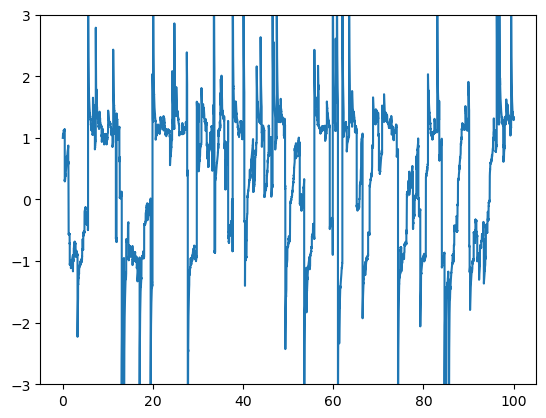

In [27]:
alpha = .8
sigma = .6
k = -0.39
T = 100
N = 1000
h = 1.0/N
x = 1

X = np.zeros(T*N+1, dtype=float)

X[0] = x

for n in range(1,T*N+1):
    xi = stable_rv(alpha)
    y =  X[n-1] - k*h + sigma*np.power(h,1/alpha)*xi
    X[n] = Phi(h, y)

plt.plot(np.linspace(0,T,T*N+1),X)
plt.ylim(-3, 3)
plt.show()

#print("time used = ",time.time()-start_time)